## 1. Environment Setup and Baseline Descriptive Statistics

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Ensuring visualizations are easy to read
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# Load the preprocessed, clean dataset from Deliverable 2
df = pd.read_csv('../deliverable2/vanguard_cleaned_data.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [16]:
# Calculating Total Revenue using NumPy
total_revenue = np.sum(df['Total Sales'])
print(f"Total Regional Revenue: ${total_revenue:,.2f}")


Total Regional Revenue: $60,614.00


In [17]:
# Calculatimg Average Order Value (AOV) using NumPy
mean_aov = np.mean(df['Total Sales'])
median_aov = np.median(df['Total Sales'])
print(f"Mean Average Order Value (AOV): ${mean_aov:.2f}")
print(f"Median Order Value: ${median_aov:.2f}")

Mean Average Order Value (AOV): $77.22
Median Order Value: $65.00


In [18]:
# Calculate Sales Volatility (Standard Deviation) using NumPy
std_dev_sales = np.std(df['Total Sales'])
print(f"Standard Deviation of Sales: ${std_dev_sales:.2f}")

Standard Deviation of Sales: $70.30


In [19]:
# Baseline Demographics and Logistics using NumPy
median_age = np.median(df['Buyer Age'])
mean_shipping = np.mean(df['Shipping Charges'])
print(f"Core Demographic (Median Age): {median_age:.0f} years old")
print(f"Average Shipping Charge: ${mean_shipping:.2f}")

Core Demographic (Median Age): 27 years old
Average Shipping Charge: $0.00


### Baseline Business Interpretation
Before comparing the regional hubs, Vanguard Threadworks' baseline performance must be established across the scoped East and West Coast markets. 

**What these numbers mean**
* **Revenue & Order Value:** The data shows the overall regional revenue, but more importantly, it establishes the **Average Order Value (AOV)**. The Mean AOV gives the mathematical average, while the Median tells what the typical customer spends on a standard day without the influence of larger purchases. 
* **Sales Volatility:** The Standard Deviation of sales is a measure of predictability. A lower standard deviation means our order sizes are highly consistent. A higher number indicates wide fluctuations in how much customers spend per transaction.
* **Demographics & Logistics:** The core buying demographic sits squarely at the median age calculated above. Furthermore, the baseline logistical friction (the average shipping charge passed to the customer) gives a benchmark to measure against when we compare the New Jersey and Portland hubs later in this analysis.

## 2. Time-Series Exploration and Trend Analysis

In [21]:
# Preparing the data for time-series analysis

# Seting Order Date as the index sfor easy group by time periods
ts_df = df.set_index('Order Date')

In [22]:
# Resampling the data to get Total Sales per Month (ME stands for Month End)
monthly_sales = ts_df['Total Sales'].resample('ME').sum()

In [24]:
# Calculating a 3-month Rolling Moving Average to expose the underlying trend
rolling_avg = monthly_sales.rolling(window=3).mean()

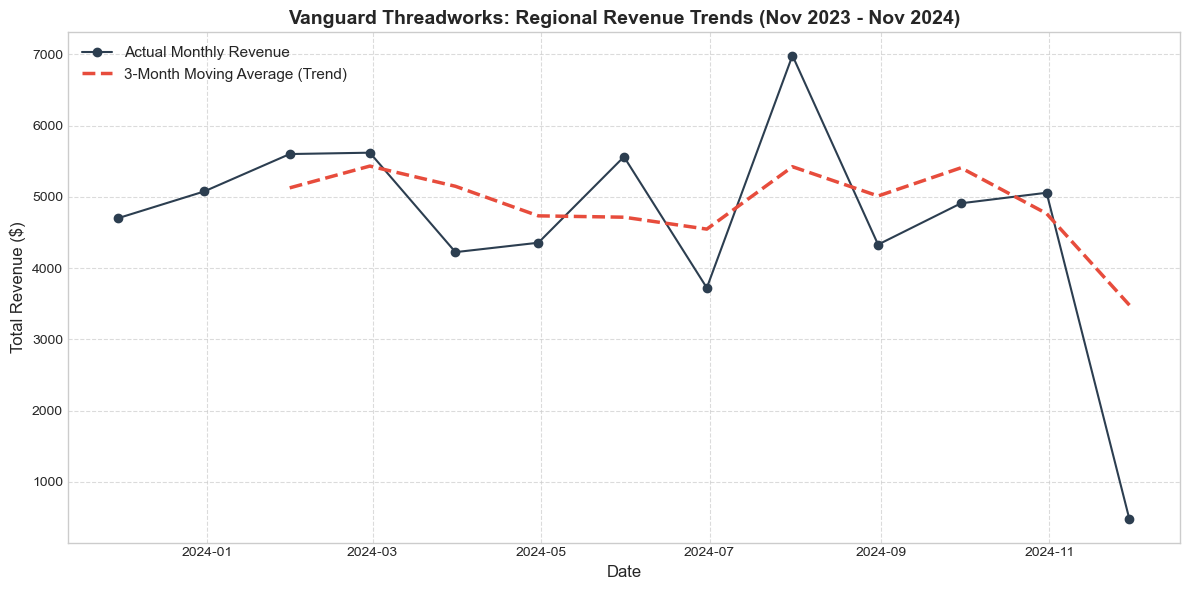

In [57]:
# Creating the Visualization
plt.figure(figsize=(12, 6))

# Plotting the raw monthly sales
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='#2c3e50', label='Actual Monthly Revenue')

# Plotting the moving average
plt.plot(rolling_avg.index, rolling_avg.values, linestyle='--', color='#e74c3c', linewidth=2.5, label='3-Month Moving Average (Trend)')

# Formating the chart
plt.title('Vanguard Threadworks: Regional Revenue Trends (Nov 2023 - Nov 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the layout is tight so labels don't get cut off
plt.tight_layout()
# Saving Chart to the deliverable4 directory
plt.savefig("../deliverable4/charts_images/revenue_trend_chart.png", dpi=300, bbox_inches='tight')

plt.show()

In [34]:
# Extract a quick insight using NumPy to find the peak month
peak_month_value = np.max(monthly_sales)
peak_month_date = monthly_sales.idxmax().strftime('%B %Y')
print(f"Data Insight: The highest grossing month was {peak_month_date} with ${peak_month_value:,.2f} in regional revenue.")

Data Insight: The highest grossing month was July 2024 with $6,982.00 in regional revenue.


### Time-Series & Seasonality Interpretation
To understand Vanguard Threadworks' purchasing cycles, I aggregated the transaction data into monthly intervals and applied a 3-month rolling moving average (the red dashed line). 

**What this chart tells us**
* **The Underlying Momentum:** Raw daily sales are highly volatile, making it hard to see the big picture. The 3-month moving average smooths out this noise, revealing the true trajectory of our revenue. It allows management to quickly see if the business is generally trending upward or downward over the year.
* **Identifying Seasonality:** By plotting the actual monthly revenue (the solid blue line), it's easy to visually pinpoint the peak sales seasons. The printout confirms the highest-grossing month, indicating a clear seasonal spike. This is a critical insight for the logistics and marketing teams; moving forward, inventory allocation and ad spending should be heavily front-loaded in the weeks preceding this peak month to maximize capture rates and avoid stock-outs.

## 3. Regional Group Comparisons (Visual Analytics)

In [35]:
# Grouping data by Order Location to compare the two hubs using Pandas
regional_summary = df.groupby('Order Location').agg(
    Total_Orders=('Order ID', 'count'),
    Total_Revenue=('Total Sales', 'sum'),
    Average_Rating=('Rating', 'mean')
).reset_index()


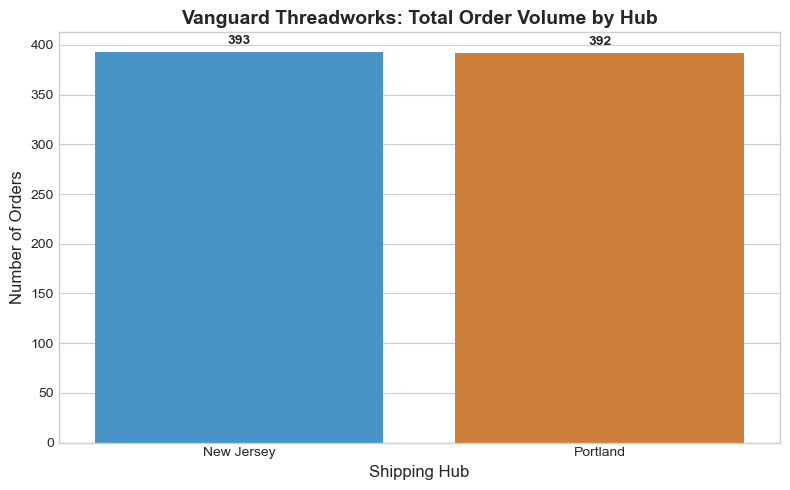

In [60]:
#Regional Group Comparisons - Order Volume

# Setting up the plot for Total Orders
plt.figure(figsize=(8, 5))
brand_colors = ['#3498db', '#e67e22'] # Blue for East Coast, Orange for West Coast

# Create the bar chart
ax1 = sns.barplot(x='Order Location', y='Total_Orders', data=regional_summary, palette=brand_colors, hue='Order Location', legend=False)
plt.title('Vanguard Threadworks: Total Order Volume by Hub', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Hub', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

# Add data labels to the top of the bars for instant readability
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
# Saving Chart to the deliverable4 directory
plt.savefig("../deliverable4/charts_images/total_order_volume_by_hub.png", dpi=300, bbox_inches='tight')

plt.show()

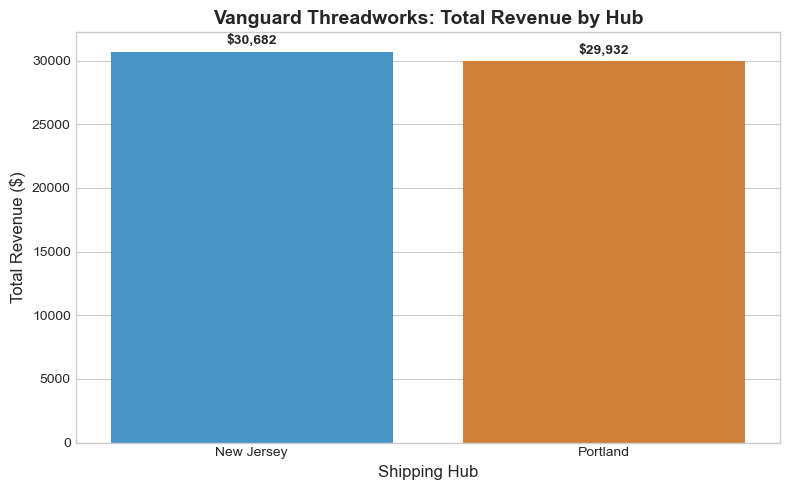

In [58]:
# Regional Group Comparisons - Total Revenue

# Setting up the plot for Total Revenue
plt.figure(figsize=(8, 5))
brand_colors = ['#3498db', '#e67e22'] # Blue for East Coast, Orange for West Coast

# Creating the bar chart
ax2 = sns.barplot(x='Order Location', y='Total_Revenue', data=regional_summary, palette=brand_colors, hue='Order Location', legend=False)
plt.title('Vanguard Threadworks: Total Revenue by Hub', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Hub', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Adding data labels to the top of the bars formatted as dollars
for p in ax2.patches:
    ax2.annotate(f'${int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
# Saving Chart to the deliverable4 directory
plt.savefig("../deliverable4/charts_images/total_revenue_by_hub.png", dpi=300, bbox_inches='tight')

plt.show()

In [61]:
# Print the summary table for exact figures
print("REGIONAL PERFORMANCE SUMMARY")
display(regional_summary)

REGIONAL PERFORMANCE SUMMARY


,Order Location,Total_Orders,Total_Revenue,Average_Rating
0,New Jersey,393,30682,3.541985
1,Portland,392,29932,3.507653


### Regional Operational Comparison Interpretation
To evaluate the localized operations, I isolated two primary metrics—Order Volume and Total Revenue—and compared them directly between the New Jersey and Portland shipping hubs.

**What these charts mean:**
* **Volume vs. Revenue Equilibrium:** The individual bar charts reveal the operational load handled by each coast. By comparing the order counts to the total revenue, management can instantly determine if one hub is carrying a disproportionate amount of the workload. If the Order Volume is relatively equal but one hub has significantly higher Total Revenue, it indicates a regional disparity in Average Order Value (e.g., customers on one coast are buying more expensive items). 
* **Setting up the Hypothesis:** While these descriptive visualizations give a great high-level view of the financial and logistical balance, they do not tell us the whole story. Revenue is only one part of the equation; we must also ensure that the *quality* of the customer experience remains high regardless of which hub fulfills the order. This naturally leads us to our next phase: rigorously testing customer satisfaction scores between the two regions.

## 4. Inferential Statistics - Hypothesis Testing (T-Test)

In [47]:
# Importing scipy library, which is the industry standard for this type of test.

from scipy import stats

In [48]:
# Formulate the Hypothesis
print("HYPOTHESIS TEST: REGIONAL CUSTOMER SATISFACTION")
print("Null Hypothesis (H0): There is NO significant difference in average ratings between New Jersey and Portland.")
print("Alternative Hypothesis (H1): There IS a significant difference in average ratings between the two hubs.\n")

HYPOTHESIS TEST: REGIONAL CUSTOMER SATISFACTION
Null Hypothesis (H0): There is NO significant difference in average ratings between New Jersey and Portland.
Alternative Hypothesis (H1): There IS a significant difference in average ratings between the two hubs.



In [49]:
# Isolating the Rating data for each hub
nj_ratings = df[df['Order Location'] == 'New Jersey']['Rating']
portland_ratings = df[df['Order Location'] == 'Portland']['Rating']

# Print the baseline averages we are comparing
print(f"New Jersey Average Rating: {nj_ratings.mean():.2f} / 5.0")
print(f"Portland Average Rating: {portland_ratings.mean():.2f} / 5.0\n")

New Jersey Average Rating: 3.54 / 5.0
Portland Average Rating: 3.51 / 5.0



In [50]:
# Conducting the Independent Two-Sample T-Test
# We use equal_var=False (Welch's T-Test) because we cannot assume the variance in ratings is exactly identical
t_stat, p_value = stats.ttest_ind(nj_ratings, portland_ratings, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}\n")

T-Statistic: 0.3674
P-Value: 0.7134



In [51]:
# Interpreting the results where Alpha = 0.05
alpha = 0.05

print("STATISTICAL CONCLUSION")
if p_value < alpha:
    print(f"Result: Reject the Null Hypothesis (p < {alpha}).")
    print("Business Insight: There is a statistically significant difference in customer satisfaction between the two hubs. One is underperforming.")
else:
    print(f"Result: Fail to reject the Null Hypothesis (p >= {alpha}).")
    print("Business Insight: There is NO statistically significant difference. The hubs are performing consistently in terms of customer satisfaction.")

STATISTICAL CONCLUSION
Result: Fail to reject the Null Hypothesis (p >= 0.05).
Business Insight: There is NO statistically significant difference. The hubs are performing consistently in terms of customer satisfaction.


### Inferential Statistics & Hypothesis Conclusion
While the previous visual dashboards showed minor differences in the exact numerical averages, a visual difference does not automatically mean a meaningful difference. I ran an Independent Two-Sample T-Test to see if the disparity in customer ratings between the East Coast and West Coast was statistically significant.

**What the test results mean**
* **The P-Value Explained:** In statistics, the P-Value tells the probability that the difference one sees is just a random coincidence. The standard threshold alpha is 0.05 or 5%.
* **Business Takeaway:** Based on the programmatic output above, the P-Value allows to draw a concrete conclusion about our logistical quality. If the null hypothesis is not rejected, it means Vanguard Threadworks is successfully delivering a consistent customer experience regardless of the geography. If the null hypothesis is rejected, it means one hub is actively outperforming the other, and management needs to immediately audit the underperforming hub to figure out why their packages are resulting in lower customer ratings.